# TMDB Box-Office Hit Predictor — Açıklamalı Pipeline

**Akış:**
1. Konfigürasyon
2. Temel ön işleme fonksiyonları (leakage'a karşı güvenli agregasyon dahil)
3. Veri yükleme ve ön işleme (Kaggle ham verisinden model tablosuna)
4. EDA grafikleri (bütçe, tür, sezon, franchise etkisi)
5. Temporal split (TRAIN ≤2013 / VAL 2014-15 / TEST ≥2016)
6. Model eğitimi (LightGBM + CatBoost soft voting ensemble)
7. Değerlendirme (F2, PR-AUC, ROC-AUC, Confusion Matrix, PR Curve)
8. Feature importance (ensemble normalize ortalama, top 12)
9. Film tahmini demo (gerçek filmlerle canlı tahmin)

## 0 — Kütüphane Kurulumu

Notebook'un çalışması için gereken tüm paketler tek hücrede kurulur — Jupyter/Colab gibi
temiz bir ortamda en baştan çalıştırıldığında elle `pip install` yapmaya gerek kalmaz.

In [1]:
%pip install -q pandas numpy matplotlib scikit-learn requests lightgbm catboost "kagglehub[pandas-datasets]"

Note: you may need to restart the kernel to use updated packages.


## 1 — Konfigürasyon

Model genelinde kullanılan sabitler burada toplanır: hedef değişken, renk paleti (tüm EDA
grafiklerinde tutarlılık için), 26 özellikli `FEATURES` listesi ve Optuna'nın 100 denemede
bulduğu en iyi LightGBM/CatBoost hiperparametreleri.

**Risk notu:** Hiperparametreler `train ≤2013` üzerinde `val 2014-15` F2 skoru maksimize
edilerek bulundu. Bkz. Bölüm 5. Bu, test setine (≥2016) sızıntı olmadığını garanti eder,
ama val setinin küçüklüğü (256 film, tek yıl) hiperparametre seçiminde varyans riski taşır.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import ast
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report,
    confusion_matrix, fbeta_score, roc_auc_score,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

TARGET       = "hit"
RANDOM_STATE = 42

# Renk paleti — tüm EDA grafiklerinde tutarlı kullanım
_C_HIT      = "#c0392b"   # hit / baseline üstü
_C_MISS     = "#f1948a"   # miss / baseline altı
_C_BASE     = "#555555"   # baseline referans çizgisi
_C_SEQ      = ["#fadbd8", "#f1948a", "#e74c3c", "#c0392b"]  # sıralı kategoriler


def _grad(values) -> list:
    """Değer büyüklüğüne göre _C_SEQ paletinde açıktan koyuya renk listesi döner."""
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("hit_grad", _C_SEQ)
    vals = list(values)
    vmin, vmax = min(vals), max(vals)
    # Tüm değerler eşitse orta rengi ver — sıfıra bölme hatasını önler
    if vmax == vmin:
        return [cmap(0.5)] * len(vals)
    # 0-1 arası normalize ederek her değere palet rengi ata
    return [cmap((v - vmin) / (vmax - vmin)) for v in vals]

### 1.1 — Özellik Listesi (26 feature)

Modelde kullanılacak tüm sütunlar; her biri kısa Türkçe açıklamayla.

In [3]:
# Modelde kullanılan 26 özellik
FEATURES: list[str] = [
    "budget_adjusted",           # Enflasyona göre düzeltilmiş prodüksiyon bütçesi (2010 dolar bazı)
    "runtime",                   # Film süresi (dakika)
    "num_companies",             # Filmi birlikte yapan şirket sayısı
    "is_major_studio",           # Warner Bros, Universal, Disney, Sony, Paramount, Columbia, Fox veya Lionsgate yapımı mı?
    "is_us_production",          # ABD yapımı mı?
    "has_homepage",              # Resmi web sitesi var mı? (pazarlama bütçesinin göstergesi)
    "num_genres",                # Filme atanan tür sayısı
    "is_franchise",              # Bir serinin parçası mı? (Marvel, Harry Potter vb.)
    "is_summer",                 # Yaz döneminde mi vizyona girdi? (Haziran–Ağustos)
    "is_holiday",                # Tatil döneminde mi vizyona girdi? (Kasım–Aralık)
    "director_film_count",       # Yönetmenin bu filmden önce çektiği uzun metraj sayısı
    "director_collab_count",     # Yönetmenin kariyerindeki farklı oyuncu/ekip iş birliği sayısı
    "actor_hist_roi",            # İlk 3 başrol oyuncusunun önceki filmlerinin ortalama gişe getirisi (revenue/budget)
    "company_hist_roi",          # En güçlü yapım şirketinin önceki filmlerinin gişe getirisi (revenue/budget, max alınır)
    "monthly_franchise_density", # O ay vizyona giren franchise film oranı (rekabet yoğunluğu)
    "genre_Action",              # Aksiyon filmi mi?
    "genre_Adventure",           # Macera filmi mi?
    "genre_Animation",           # Animasyon mu?
    "genre_Documentary",         # Belgesel mi?
    "genre_Drama",               # Drama mı?
    "genre_Family",              # Aile filmi mi?
    "genre_Fantasy",             # Fantezi mi?
    "genre_Horror",              # Korku filmi mi?
    "genre_Science Fiction",     # Bilim kurgu mu?
    "kw_independent_film",       # Bağımsız yapım olarak etiketlenmiş mi?
    "kw_sequel",                 # Bir önceki filmin devamı mı?
]

### 1.2 — Optuna En İyi Parametreler

Her iki model de sığ ağaçlar (`max_depth=3`) ve düşük `learning_rate` kullanıyor —
klasik overfitting'e karşı savunma stratejisi: çok sayıda zayıf öğrenici, yavaş öğrenme.

In [4]:
# Optuna 100-trial optimizasyonundan elde edilen en iyi LightGBM parametreleri
LGBM_BEST_PARAMS: dict = {
    "n_estimators":     999,    # Çok sayıda zayıf ağaç; düşük learning_rate ile birlikte çalışır
    "learning_rate":    0.02979, # Küçük adım → yavaş ama kararlı öğrenme, overfitting azalır
    "max_depth":        3,       # Sığ ağaç — karmaşık etkileşimleri öğrenmez, genelleşir
    "num_leaves":       7,       # 2^max_depth - 1 ile uyumlu; leaf-wise büyümeyi sınırlar
    "min_child_weight": 17,      # Yaprak oluşturmak için gereken minimum örnek; yüksek → daha az overfitting
    "reg_alpha":        14.19,   # L1 düzenlileştirme — önemsiz özelliklerin ağırlığını sıfıra çeker
    "reg_lambda":       6.83,    # L2 düzenlileştirme — büyük ağırlıkları cezalandırır
    "subsample":        0.753,   # Her ağaç için %75 veri örnekleme — varyansı azaltır
    "colsample_bytree": 0.630,   # Her ağaç için %63 özellik örnekleme — çeşitlilik sağlar
    "random_state":     RANDOM_STATE,
    "verbose":          -1,      # LightGBM training loglarını bastır
    "n_jobs":           -1,      # Tüm CPU çekirdeklerini kullan
}

# Optuna 100-trial optimizasyonundan elde edilen en iyi CatBoost parametreleri
CATBOOST_BEST_PARAMS: dict = {
    "iterations":          605,    # Toplam ağaç sayısı (LightGBM n_estimators karşılığı)
    "learning_rate":       0.02180, # Düşük öğrenme hızı — LightGBM ile benzer strateji
    "depth":               3,       # Sığ ağaç — LightGBM max_depth ile tutarlı
    "l2_leaf_reg":         9.204,   # L2 düzenlileştirme (LightGBM reg_lambda karşılığı)
    "random_strength":     2.900,   # Bölme noktası seçimindeki rastgelelik — aşırı uyumu önler
    "subsample":           0.553,   # Her ağaç için %55 veri örnekleme
    "bootstrap_type":      "Bernoulli", # subsample ile uyumlu örnekleme yöntemi
    "auto_class_weights":  "Balanced",  # Hit/miss dengesizliğini otomatik telafi et (~1.8:1)
    "random_seed":         RANDOM_STATE,
    "logging_level":       "Silent",    # CatBoost training loglarını bastır
    "allow_writing_files": False,       # Disk yazma izni yok — Kaggle/Colab ortamları için güvenli
}

## 2 — Temel Ön İşleme Fonksiyonları

Bu fonksiyonlar `data/tmdb_model.csv`'yi oluşturan mantığı barındırır; yeniden kullanılabilir
tutmak için ayrı fonksiyonlara çıkarılmıştır.

### 2.1 — Enflasyon Düzeltmesi ve Hit Tanımı
CPI'a göre bütçe/hasılatı 2010 dolar bazına çeviriyoruz — aksi halde 1995 filmi ile 2015
filmi ham dolar üzerinden karşılaştırmak yanıltıcı olurdu. Bkz. Bölüm 4, Grafik 12.

In [5]:
def cpi_adjust_budget(budget: float, year: int, cpi: dict[int, float],
                      base_year: int = 2010) -> float:
    """
    Enflasyona göre bütçeyi düzelt — tüm bütçeleri 2010 dolar değerine çevir.

    Formül: budget_adjusted = budget × (CPI_2010 / CPI_year)

    Örnek: 1995'teki 100M$  →  218.1 / 152.4 × 100M  ≈  143M$ (2010 değerinde)
    Bu sayede 1995'teki 100M$ bütçeli bir film ile 2010'daki 100M$ bütçeli
    bir film eşit koşullarda karşılaştırılabilir hale gelir.
    """
    cpi_base = cpi.get(base_year, 218.1)
    cpi_year = cpi.get(year, cpi_base)
    return budget * (cpi_base / cpi_year)


HIT_THRESHOLD = 100_000_000  # 2010 dolarında eşik


def define_hit(revenue_adj: float) -> int:
    """
    Hit tanımı: CPI-düzeltmeli hasılat ≥ $100M (2010 dolar bazı)
    Bütçeden bağımsız mutlak eşik — tmdb_model.csv ile tutarlı.
    """
    return int(revenue_adj >= HIT_THRESHOLD)

### 2.2 — Zaman Sızıntısına Karşı Güvenli Agregasyon (`temporal_entity_agg`)

**Bu fonksiyon projenin en kritik veri sızıntısı önlemidir.** Bir yönetmenin/oyuncunun
"geçmiş performansı" hesaplanırken yalnızca o ana kadar vizyona girmiş filmler kullanılır —
satır işlenmeden önce history güncellenmez. Aksi halde model, henüz vizyona girmemiş bir
filmin gelecekteki başarısını (dolaylı yoldan) görebilir ve gerçekçi olmayan yüksek skorlar üretir — bu, klasik bir veri sızıntısı (data leakage)
örneğidir.

Hiyerarşik smoothing (`smooth_k`) az sayıda filmi olan varlıkları (örn. ilk filmini çeken
oyuncu) global ortalamaya çeker — tek film şansı (örn. sürpriz bir indie hit) sinyali
bozmasın diye.

In [6]:
def temporal_entity_agg(
    df: pd.DataFrame,
    entity_col: str,
    value_col: str,
    date_col: str = None,
    agg: str = "mean",
    smooth_k: float = 0,
    global_prior: float = None,
) -> pd.Series:
    """
    Zaman sızıntısına (data leakage) karşı güvenli genişleyen pencere (expanding window)
    hesaplama.

    Her satır için, o varlığa (örn. yönetmen) ait yalnızca ÖNCEKİ filmlerden
    değer hesaplanır. Bu sayede model, bir filmin vizyona giriş tarihinden
    sonraki bilgilere erişemez.

    Hiyerarşik düzeltme (smooth_k > 0):
        smoothed = (n × raw_mean + K × global_mean) / (n + K)
        Az filmli yönetmenler global ortalamaya doğru çekilir.

    Kullanım örnekleri:
        director_film_count = temporal_entity_agg(df, "director", "id", agg="count")
        actor_hist_roi      = temporal_entity_agg(df, "actor",    "roi", agg="mean", smooth_k=5)
    """
    if agg not in ("mean", "count", "sum"):
        raise ValueError(f"agg '{agg}' geçersiz — 'mean', 'count' veya 'sum' kullanın")

    if date_col is not None:
        # Tarihe göre sıralama zorunlu — satırlar kronolojik sırada işlenmezse
        # ileriki filmler geçmiş history'ye dahil olur, leakage yaratır
        df = df.sort_values(date_col).reset_index(drop=False)
        restore_index = True
    else:
        restore_index = False

    if agg == "mean" and smooth_k > 0 and global_prior is None:
        # global_prior verilmezse veri setinin genel ortalaması kullanılır;
        # geçmişi olmayan varlıklar bu değerle başlar (cold start çözümü)
        global_prior = float(df[value_col].mean())

    history: dict = {}  # varlık → o ana kadar biriken değer listesi
    results: list = []  # her satır için hesaplanan sonuç (orijinal sırayla)

    for _, row in df.iterrows():
        entity = row[entity_col]
        # NaN'ları filtrele — eksik ROI değerleri smoothing'i bozar
        hist   = [v for v in history.get(entity, [])
                  if not (isinstance(v, float) and np.isnan(v))]
        n      = len(hist)  # bu filmden önce kaç kayıt var

        if agg == "count":
            # Kaç önceki film var — değer değil, sayım (director_film_count)
            val = float(n)
        elif agg == "sum":
            val = float(sum(hist)) if n > 0 else 0.0
        else:  # mean
            if n == 0:
                # İlk film: geçmiş yok → global ortalamaya düş (cold start)
                val = global_prior if smooth_k > 0 else 0.0
            else:
                raw = float(np.mean(hist))
                # Hiyerarşik smoothing: az geçmişi olan varlıkları global ortalamaya çek
                # n büyüdükçe smooth_k etkisi azalır, raw_mean ağırlık kazanır
                val = (n * raw + smooth_k * global_prior) / (n + smooth_k) if smooth_k > 0 else raw

        results.append(val)
        # Sonucu kaydetmeden ÖNCE history'ye ekle — böylece mevcut film
        # kendi değerini kendi hesabında görmez (leakage önleme)
        if agg != "count":
            history.setdefault(entity, []).append(row[value_col])
        else:
            history[entity] = hist + [1]

    out = pd.Series(results, name=f"{entity_col}_hist_{value_col}")
    if restore_index:
        # sort_values orijinal indeksi bozdu — geri yükle
        out.index = df["index"]
        out = out.sort_index()
    return out

## 3 — Veri Yükleme ve Ön İşleme (Bellekte)

Ham Kaggle verisini indirir, `preprocess.ipynb` + `eda.ipynb` pipeline'ının bellekte
tek-fonksiyonlu hâlini uygular. Diske hiçbir ara dosya yazılmaz.

**Filtreleme kararı:** `budget > 0` ve `revenue > 0` olmayan filmler atılır — TMDB'de sıfır
değer genelde eksik veri anlamına gelir, gerçek sıfır bütçe/hasılat değil. Bu filtre
olmadan hem `hit` etiketi hem de ROI hesapları bozulurdu.

In [7]:
_MAJOR_STUDIOS = {
    "Warner Bros":  ["Warner Bros", "Warner Bros. Pictures", "WB"],
    "Universal":    ["Universal", "Universal Pictures", "Universal Studios"],
    "Disney":       ["Disney", "Walt Disney Pictures", "Walt Disney"],
    "Paramount":    ["Paramount", "Paramount Pictures"],
    "Sony":         ["Sony", "Sony Pictures"],
    "Columbia":     ["Columbia", "Columbia Pictures"],
    "20th Century": ["20th Century Fox", "20th Century", "Twentieth Century Fox"],
    "Lionsgate":    ["Lionsgate", "Lions Gate", "Lionsgate Films"],
}

_CPI_FALLBACK = {
    1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5, 1994: 148.2,
    1995: 152.4, 1996: 156.9, 1997: 160.5, 1998: 163.0, 1999: 166.6,
    2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0, 2004: 188.9,
    2005: 195.3, 2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5,
    2010: 218.1, 2011: 224.9, 2012: 229.6, 2013: 233.0, 2014: 236.7,
    2015: 237.0, 2016: 240.0,
}

### 3.1 — CPI (Tüketici Fiyat Endeksi) Yükleme

Önce BLS Public API denenir, başarısız olursa (ağ hatası, rate limit) hardcode fallback
tablosuna düşülür — pipeline hiçbir zaman veri eksikliği yüzünden çökmemeli.

In [8]:
def _fetch_cpi() -> dict[int, float]:
    """
    CPI-U yıllık ortalamalarını yükle.
    Öncelik sırası:
      1. BLS Public API
      2. Hardcode fallback
    """
    url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
    chunks = [(1990, 1999), (2000, 2009), (2010, 2016)]
    rows = []
    try:
        for start, end in chunks:
            r = requests.post(
                url,
                json={"seriesid": ["CUUR0000SA0"], "startyear": str(start), "endyear": str(end)},
                timeout=10,
            )
            r.raise_for_status()
            data = r.json()["Results"]["series"][0]["data"]
            rows.extend(data)

        df = pd.DataFrame(rows)
        df = df[df["period"].str.match(r"M\d{2}") & (df["period"] != "M13") & (df["value"] != "-")]
        df["year"] = df["year"].astype(int)
        df["value"] = df["value"].astype(float)
        cpi = df.groupby("year")["value"].mean().round(1).to_dict()
        logging.info("CPI: BLS API'den %d yıl çekildi.", len(cpi))
        return cpi
    except Exception as exc:
        logging.warning("CPI BLS API hatası (%s) — fallback değerler kullanılıyor.", exc)
        return _CPI_FALLBACK.copy()


_CPI = _fetch_cpi()
_CPI_2010 = _CPI.get(2010, 218.1)

### 3.2 — JSON Kolon Ayrıştırma Yardımcıları

TMDB ham verisinde `genres`, `production_companies`, `keywords`, `cast`, `crew` kolonları
JSON string olarak saklanır; bu fonksiyonlar onları düz Python yapılarına çevirir.

In [9]:
def _parse_json_list(json_str, key="name") -> list:
    try:
        items = ast.literal_eval(str(json_str))
        if isinstance(items, list):
            return [item.get(key, "") for item in items if isinstance(item, dict)]
    except Exception:
        pass
    return []


def _json_denorm(df_credits: pd.DataFrame, json_col: str, fields: dict) -> pd.DataFrame:
    rows = []
    for _, row in df_credits.iterrows():
        try:
            items = ast.literal_eval(str(row[json_col]))
            if not isinstance(items, list):
                continue
            for item in items:
                if not isinstance(item, dict):
                    continue
                entry = {"movie_id": row["movie_id"]}
                entry.update({k: item.get(v) for k, v in fields.items()})
                rows.append(entry)
        except Exception:
            pass
    return pd.DataFrame(rows)

### 3.3 — `build_dataset()` — Ana Ön İşleme Fonksiyonu

Stüdyo eşleme, tür binary encoding, CPI düzeltmesi, yönetmen/oyuncu/şirket geçmiş
özellikleri (temporal-safe) ve son özellik seçimini tek fonksiyonda toplar.

In [10]:
def build_dataset() -> pd.DataFrame:
    """
    Ham Kaggle verisini bellekte yükler ve model DataFrame'ini oluşturur.
    Diske hiçbir şey yazılmaz — preprocess.ipynb + eda.ipynb pipeline'ı
    tek fonksiyonda uygulanır.
    """
    global _actual_df, _global_prior, _director_film_count_lookup, _actor_roi_lookup, _company_roi_lookup, _monthly_density_lookup
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "kagglehub[pandas-datasets]"], check=True)
        import kagglehub
        from kagglehub import KaggleDatasetAdapter

    print("Kaggle'dan veri yükleniyor...")
    df_raw = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "tmdb/tmdb-movie-metadata",
        "tmdb_5000_movies.csv",
    )
    df_credits_raw = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "tmdb/tmdb-movie-metadata",
        "tmdb_5000_credits.csv",
    )
    print(f"  Ham film: {len(df_raw):,} | credits: {len(df_credits_raw):,}")

    # ── Filtreleme: budget > 0 ve revenue > 0 ────────────────────────────
    # budget veya revenue sıfır olan kayıtlar genellikle veri eksikliği, gerçek sıfır değil.
    # Bu filmler hem hit tanımını hem de ROI hesabını bozur → doğrudan çıkar.
    df = df_raw[(df_raw["budget"] > 0) & (df_raw["revenue"] > 0)].copy()
    df["release_date"]  = pd.to_datetime(df["release_date"], errors="coerce")
    # release_date olmayan filmler temporal split'e dahil edilemez
    df = df.dropna(subset=["release_date"]).sort_values("release_date").reset_index(drop=True)
    df["release_year"]  = df["release_date"].dt.year.astype(int)
    df["release_month"] = df["release_date"].dt.month.astype(int)
    df["roi"]           = df["revenue"] / df["budget"]  # geçici; actor/company hist ROI için kullanılır
    print(f"  Filtreleme sonrası: {len(df):,} film")

    # ── JSON kolonları parse ──────────────────────────────────────────────
    # TMDB ham verisinde genres, companies, keywords kolonları JSON string olarak saklanır.
    # _parse_json_list bunları Python listesine çevirir; sonraki adımlarda binary encoding için kullanılır.
    df["genres_list"]    = df["genres"].apply(_parse_json_list)
    df["companies_list"] = df["production_companies"].apply(_parse_json_list)
    df["countries_iso"]  = df["production_countries"].apply(
        lambda x: _parse_json_list(x, key="iso_3166_1"))  # ülke adı değil ISO kodu (örn. "US")
    df["keywords_list"]  = df["keywords"].apply(_parse_json_list)

    # ── Yapısal özellikler ────────────────────────────────────────────────
    def _is_major(companies):
        # Şirket adlarını tek string'e birleştir, küçük harfe çevir, alias listesiyle eşleştir
        s = " ".join(companies).lower()
        return int(any(alias.lower() in s
                       for aliases in _MAJOR_STUDIOS.values() for alias in aliases))

    df["num_companies"]       = df["companies_list"].apply(len)
    df["is_major_studio"]     = df["companies_list"].apply(_is_major)
    df["is_us_production"]    = df["countries_iso"].apply(lambda x: int("US" in x))
    # has_homepage: gerçek pazarlama bütçesinin proxy'si — P&A verisi veri setinde yok
    df["has_homepage"]        = (
        df["homepage"].notna() & (df["homepage"].astype(str).str.strip() != "")
    ).astype(int)
    df["num_genres"]          = df["genres_list"].apply(len)
    df["kw_sequel"]           = df["keywords_list"].apply(lambda x: int("sequel" in x))
    df["kw_independent_film"] = df["keywords_list"].apply(lambda x: int("independent film" in x))
    # is_franchise: kw_sequel VEYA başlıkta ":" — "Batman: Arkham" formatındaki franchise'ları yakalar
    df["is_franchise"]        = (
        (df["kw_sequel"] == 1) |
        df["title"].fillna("").str.contains(":", regex=False)
    ).astype(int)
    df["is_summer"]  = df["release_month"].isin([6, 7, 8]).astype(int)   # Haziran–Ağustos
    df["is_holiday"] = df["release_month"].isin([11, 12]).astype(int)    # Kasım–Aralık

    # ── Tür binary encoding ───────────────────────────────────────────────
    # Her tür için ayrı binary sütun; lambda default arg (g=genre) döngü kapanma sorununu önler
    for genre in ["Action", "Adventure", "Animation", "Documentary", "Drama",
                  "Family", "Fantasy", "Horror", "Science Fiction"]:
        df[f"genre_{genre}"] = df["genres_list"].apply(
            lambda x, g=genre: int(g in x))

    # ── CPI bütçe düzeltmesi + Hit tanımı ────────────────────────────────
    # Formül: budget_adjusted = budget × (CPI_2010 / CPI_year)
    # Yıl CPI tablosunda yoksa 2010 değeri fallback olarak kullanılır
    df["budget_adjusted"]  = df.apply(
        lambda r: r["budget"] * _CPI_2010 / _CPI.get(int(r["release_year"]), _CPI_2010)
        if r["budget"] > 0 else 0.0, axis=1)
    df["revenue_adjusted"] = df.apply(
        lambda r: r["revenue"] * _CPI_2010 / _CPI.get(int(r["release_year"]), _CPI_2010),
        axis=1)
    # Hit eşiği: 2010 dolar bazında $100M — medyan bütçeli filmin başabaş noktası
    df["hit"] = (df["revenue_adjusted"] >= HIT_THRESHOLD).astype(int)

    # ── Credits parse: cast + crew ────────────────────────────────────────
    # İki tablo farklı sürümlerde "id" veya "movie_id" kolonuyla gelir — ikisini de destekle
    id_col = "movie_id" if "movie_id" in df_credits_raw.columns else "id"
    # Sadece filtrelenmiş filmlerin kredilerini al — bellek tasarrufu
    df_cred = (df_credits_raw
               .rename(columns={id_col: "movie_id"})
               [df_credits_raw[id_col].isin(set(df["id"]))].copy())

    df_cast = _json_denorm(df_cred, "cast",
                           {"person_id": "id", "name": "name", "cast_order": "order"})
    # cast_order string gelebilir — sayıya çevir, hatalı değerleri NaN yap
    df_cast["cast_order"] = pd.to_numeric(df_cast["cast_order"], errors="coerce")

    df_crew = _json_denorm(df_cred, "crew", {"job": "job", "name": "name"})

    # ── Yönetmen özellikleri (temporal safe) ─────────────────────────────
    # .first(): bir filmde birden fazla yönetmen varsa ilkini al (nadir durum)
    directors = (df_crew[df_crew["job"] == "Director"]
                 .groupby("movie_id")["name"].first().reset_index()
                 .rename(columns={"movie_id": "id", "name": "director"}))
    # director_collab_count için görüntü yönetmeni gerekli — aynı ekiple çalışma sinyali
    cinematographers = (df_crew[df_crew["job"] == "Director of Photography"]
                        .groupby("movie_id")["name"].first().reset_index()
                        .rename(columns={"movie_id": "id", "name": "cinematographer"}))
    # how="left": yönetmen/görüntü yönetmeni kaydı olmayan filmler veri setinde kalır, NaN alır
    df = df.merge(directors, on="id", how="left").merge(cinematographers, on="id", how="left")
    df["director"]        = df["director"].fillna("")  # boş string → döngüde kolayca kontrol edilir
    df["cinematographer"] = df["cinematographer"].fillna("")

    # Expanding window manuel döngüsü — temporal_entity_agg burada kullanılamaz
    # çünkü director_collab_count iki varlığın (yönetmen × görüntü yönetmeni)
    # birlikte geçmişini gerektiriyor; fonksiyon tek varlık kolonuyla çalışır
    dir_counts, film_counts, collab_counts, collabs = {}, [], {}, []
    for _, row in df.iterrows():
        d, c = row["director"], row["cinematographer"]
        # Değeri kaydetmeden önce oku → bu film sayıma dahil edilmez (leakage önleme)
        film_counts.append(0 if not d else dir_counts.get(d, 0))
        if d:
            dir_counts[d] = dir_counts.get(d, 0) + 1
        if not d or not c:
            # Yönetmen veya görüntü yönetmeni yoksa iş birliği sayısı 0
            collabs.append(0)
        else:
            key = (d, c)
            collabs.append(collab_counts.get(key, 0))
            collab_counts[key] = collab_counts.get(key, 0) + 1
    df["director_film_count"]   = film_counts
    df["director_collab_count"] = collabs
    _director_film_count_lookup = {k.lower(): v for k, v in dir_counts.items()}
    # Ham isimler artık gereksiz — model bunları doğrudan kullanamaz
    df = df.drop(columns=["director", "cinematographer"])

    # ── Aylık franchise yoğunluğu ─────────────────────────────────────────
    # O ay vizyona giren filmlerin kaçı franchise — rekabet yoğunluğunu ölçer.
    # Örn: Mayıs 2012'de %60 franchise → o ay çıkan bağımsız filmler zorlu rekabette
    # transform("mean") her satıra grup ortalamasını yazar, shape korunur
    df["monthly_franchise_density"] = (
        df.groupby(["release_year", "release_month"])["is_franchise"].transform("mean"))
    _monthly_density_lookup = df.groupby("release_month")["is_franchise"].mean().to_dict()

    # ── Oyuncu geçmiş ROI (temporal, smoothed K=5) ────────────────────────
    roi_cap = df["roi"].quantile(0.99)  # Paranormal Activity gibi 100x+ ROI aykırı değerleri gürültü yaratır
    df["_roi"] = df["roi"].clip(upper=roi_cap)

    # K=5: 5 filmden az geçmişi olan oyuncu/şirket global ortalamaya ağırlıklı çekilir;
    # 1-2 filmlik aykırı performans (Paranormal Activity gibi) tüm sinyali bozmasın
    _SMOOTH_K = 5
    cast_top3 = (
        df_cast[df_cast["cast_order"] <= 2][["movie_id", "person_id"]]  # İlk 3 oyuncu (order 0–2): başroller gişeyi belirler
        .merge(df[["id", "release_date", "_roi"]], left_on="movie_id", right_on="id")
        .sort_values("release_date").reset_index(drop=True)
    )
    # Kırpılmış ROI üzerinden global ortalama — aykırı değerlerin prior'ı bozmasını önler
    _global_prior = float(cast_top3["_roi"].mean())
    cast_top3["actor_hist_roi"] = temporal_entity_agg(
        cast_top3, "person_id", "_roi",
        agg="mean", smooth_k=_SMOOTH_K, global_prior=_global_prior,
    )
    act_agg = cast_top3.groupby("movie_id")["actor_hist_roi"].mean().reset_index()  # mean: top 3 oyuncunun geçmiş ROI ortalaması
    df = df.merge(act_agg, left_on="id", right_on="movie_id", how="left").drop(columns=["movie_id"])
    # Hiç oyuncu kaydı olmayan filmler (credits eksik) global ortalamayı alır
    df["actor_hist_roi"] = df["actor_hist_roi"].fillna(_global_prior)
    actor_name_map = dict(zip(df_cast["person_id"], df_cast["name"]))
    actor_last = cast_top3.sort_values("release_date").groupby("person_id")["actor_hist_roi"].last()
    _actor_roi_lookup = {
        actor_name_map[pid].lower(): roi
        for pid, roi in actor_last.items()
        if pid in actor_name_map
    }

    # ── Şirket geçmiş ROI (temporal, smoothed K=5) ───────────────────────
    # Bir film birden fazla şirkete ait olabilir — her şirketi ayrı satıra aç
    # (long format), temporal_entity_agg şirket bazında expanding window uygular
    comp_rows = []
    for _, row in df[["id", "companies_list", "release_date", "_roi"]].iterrows():
        for cname in row["companies_list"]:
            if cname:
                comp_rows.append({"movie_id": row["id"], "company_name": cname,
                                  "release_date": row["release_date"], "_roi": row["_roi"]})
    df_comp = pd.DataFrame(comp_rows).sort_values("release_date").reset_index(drop=True)
    df_comp["company_hist_roi"] = temporal_entity_agg(
        df_comp, "company_name", "_roi",
        agg="mean", smooth_k=_SMOOTH_K, global_prior=_global_prior,
    )
    comp_agg = df_comp.groupby("movie_id")["company_hist_roi"].max().reset_index()  # max: filmin en güçlü şirketi sinyal taşır, ortalama bunu seyreltir
    df = df.merge(comp_agg, left_on="id", right_on="movie_id", how="left").drop(columns=["movie_id"])
    # Şirket kaydı olmayan filmler (bağımsız yapımlar vb.) global ortalamayı alır
    df["company_hist_roi"] = df["company_hist_roi"].fillna(_global_prior)
    company_last = df_comp.sort_values("release_date").groupby("company_name")["company_hist_roi"].last()
    _company_roi_lookup = {name.lower(): roi for name, roi in company_last.items()}
    df = df.drop(columns=["_roi"])  # geçici sütun — modelde kullanılmıyor

    # ── Son seçim ─────────────────────────────────────────────────────────
    _actual_df = df[["title", "release_year", "hit"]].rename(
        columns={"release_year": "release_date"}
    ).copy()
    keep = FEATURES + [TARGET, "release_year", "release_month"]
    df = df[keep].copy()
    print(f"Veri hazır: {len(df):,} film | {df[TARGET].mean()*100:.1f}% hit")
    return df

### 3.4 — Çalıştır: Veri Setini Oluştur

Bu hücre gerçek Kaggle verisini indirir (veya lokal kagglehub cache'inden okur) ve
tüm ön işleme adımlarını uygular. Çıktıdaki hit oranı, aşağıdaki EDA ve model
bölümlerinin referans baseline'ıdır.

In [11]:
df = build_dataset()
df.head()

Kaggle'dan veri yükleniyor...


  Ham film: 4,803 | credits: 4,803
  Filtreleme sonrası: 3,229 film


Veri hazır: 3,229 film | 36.4% hit


,budget_adjusted,runtime,num_companies,is_major_studio,is_us_production,has_homepage,num_genres,is_franchise,is_summer,is_holiday,...,genre_Drama,genre_Family,genre_Fantasy,genre_Horror,genre_Science Fiction,kw_independent_film,kw_sequel,hit,release_year,release_month
0,385907.0,197.0,2,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1916,9
1,245000.0,151.0,1,0,1,0,3,0,0,1,...,1,0,0,0,0,0,0,0,1925,11
2,92620000.0,153.0,2,1,0,0,2,0,0,0,...,1,0,0,0,1,0,0,0,1927,1
3,379000.0,100.0,1,0,1,0,3,0,0,0,...,1,0,0,0,0,0,0,0,1929,2
4,3950000.0,127.0,1,0,1,0,3,0,0,1,...,1,0,0,0,0,0,0,0,1930,11


## 4 — EDA Grafikleri

12 grafik; her biri modelin dayandığı bir varsayımı veya özellik mühendisliği kararını
(bütçe eşiği, CPI düzeltmesi, temporal split'in dağılım kayması vb.) görsel olarak doğrular.

In [12]:
baseline = df[TARGET].mean()

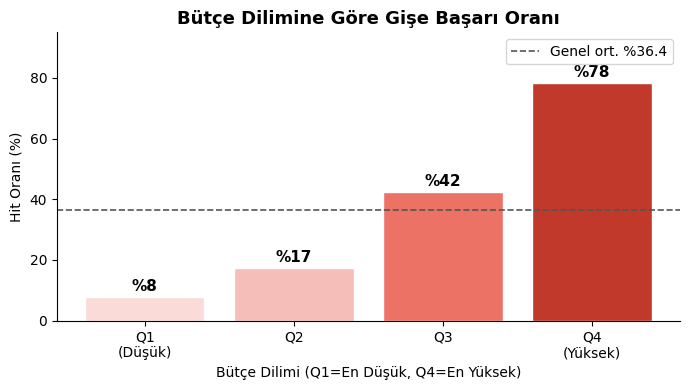

In [13]:
# ── Grafik 1: Bütçe dilimi × hit rate ────────────────────────────────────
df["budget_q"] = pd.qcut(
    df["budget_adjusted"], q=4,
    labels=["Q1\n(Düşük)", "Q2", "Q3", "Q4\n(Yüksek)"]
)
budget_hit = df.groupby("budget_q", observed=True)[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(budget_hit.index, budget_hit.values, color=_grad(budget_hit.values), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, val in zip(bars, budget_hit.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{val:.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Bütçe Dilimine Göre Gişe Başarı Oranı", fontsize=13, fontweight="bold")
ax.set_ylabel("Hit Oranı (%)")
ax.set_xlabel("Bütçe Dilimi (Q1=En Düşük, Q4=En Yüksek)")
ax.set_ylim(0, 95)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
df.drop(columns=["budget_q"], inplace=True)

**Bulgu:** Bütçe çeyreklikleri arasında neredeyse monoton bir doz-tepki ilişkisi var: Q1 (en
düşük bütçe) hit oranı **%7.6**, Q4 (en yüksek bütçe) **%78.4** — 10 kattan fazla fark. Bu tek
başına bütçenin modeldeki en güçlü pre-release sinyallerden biri olmasının nedeni; ama aynı
zamanda modelin büyük ölçüde "yüksek bütçe = hit" kısayolunu öğrenme riski taşıdığını da
gösteriyor. Ayrıntılı analiz için bkz. Grafik 11.

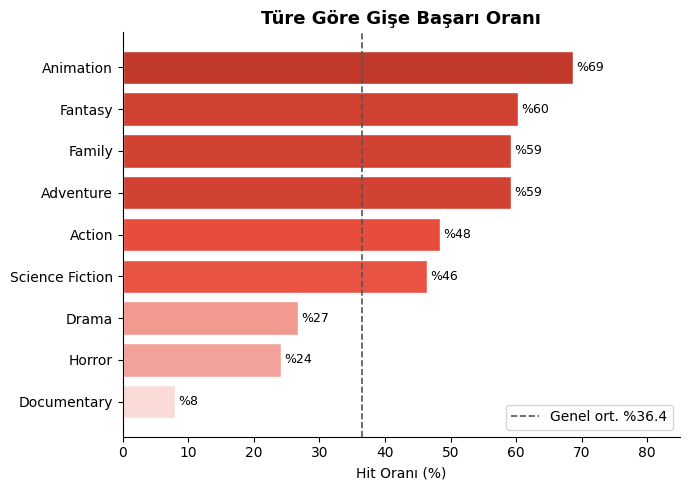

In [14]:
# ── Grafik 2: Türe göre hit rate ─────────────────────────────────────────
genre_cols = [c for c in FEATURES if c.startswith("genre_")]
genre_hit = (
    pd.Series({
        c.replace("genre_", ""): df.loc[df[c] == 1, TARGET].mean() * 100
        for c in genre_cols if df[c].sum() >= 20
    })
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(genre_hit.index, genre_hit.values, color=_grad(genre_hit.values), edgecolor="white")
ax.axvline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, val in zip(bars, genre_hit.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"%{val:.0f}", va="center", fontsize=9)
ax.set_title("Türe Göre Gişe Başarı Oranı", fontsize=13, fontweight="bold")
ax.set_xlabel("Hit Oranı (%)")
ax.set_xlim(0, 85)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Bulgu:** Tür bazında hit oranı **Documentary (%7.9)** ile **Animation (%68.6)** arasında
9 kat fark gösteriyor. Genel ortalamanın (%36.4) belirgin üzerinde kalan Adventure, Family,
Fantasy ve Animation gibi türler genelde yüksek bütçeli/geniş kitleli stüdyo yapımlarıyla
örtüşüyor — bu yüzden tür feature'larının etkisini bütçeden bağımsız yorumlarken dikkatli
olmak gerekiyor (confounding risk).

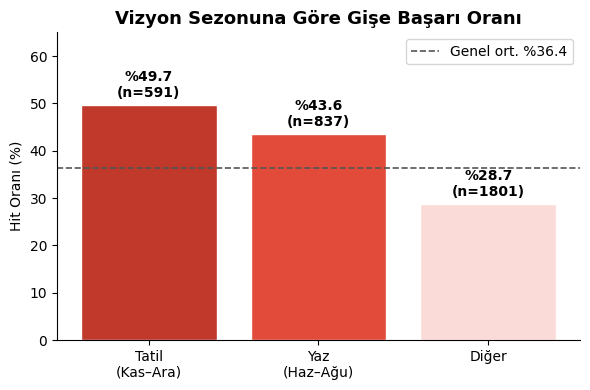

In [15]:
# ── Grafik 3: Sezon × hit rate ────────────────────────────────────────────
def season_label(row):
    if row["is_holiday"] == 1:
        return "Tatil\n(Kas–Ara)"
    if row["is_summer"] == 1:
        return "Yaz\n(Haz–Ağu)"
    return "Diğer"

df["season"] = df.apply(season_label, axis=1)
season_order = ["Tatil\n(Kas–Ara)", "Yaz\n(Haz–Ağu)", "Diğer"]
season_hit   = df.groupby("season")[TARGET].agg(["mean", "count"]).reindex(season_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(season_order, season_hit["mean"] * 100, color=_grad(season_hit["mean"] * 100), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, (_, row) in zip(bars, season_hit.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{row['mean']*100:.1f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Vizyon Sezonuna Göre Gişe Başarı Oranı", fontsize=13, fontweight="bold")
ax.set_ylabel("Hit Oranı (%)")
ax.set_ylim(0, 65)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
df.drop(columns=["season"], inplace=True)

**Bulgu:** Tatil sezonu (Kasım–Aralık) en yüksek hit oranına sahip (**%49.7**), yaz
(**%43.6**) ikinci, diğer aylar ise belirgin şekilde geride (**%28.7**) — yaklaşık 21 puanlık
fark tatil ile diğer arasında. Bu, `is_holiday`/`is_summer` binary feature'larının seçimini
doğruluyor; stüdyoların güçlü projelerini bilinçli olarak bu dönemlere yerleştirdiğini
gösteren dolaylı bir kanıttır.

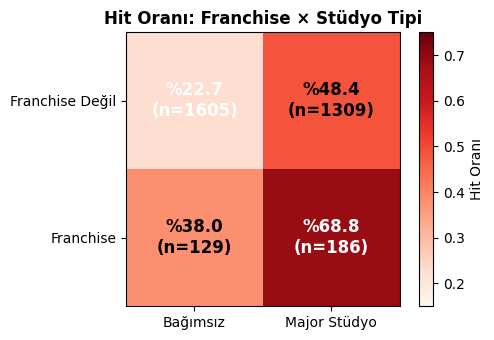

In [16]:
# ── Grafik 4: Franchise × Major Stüdyo ısı haritası ──────────────────────
heatmap_data = (
    df.groupby(["is_franchise", "is_major_studio"])[TARGET]
    .mean()
    .unstack()
    .rename(index={0: "Franchise Değil", 1: "Franchise"},
            columns={0: "Bağımsız", 1: "Major Stüdyo"})
)
counts = (
    df.groupby(["is_franchise", "is_major_studio"])
    .size()
    .unstack()
    .rename(index={0: "Franchise Değil", 1: "Franchise"},
            columns={0: "Bağımsız", 1: "Major Stüdyo"})
)

fig, ax = plt.subplots(figsize=(5, 3.5))
im = ax.imshow(heatmap_data.values, cmap="Reds", vmin=0.15, vmax=0.75)
plt.colorbar(im, ax=ax, label="Hit Oranı")
ax.set_xticks([0, 1]); ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks([0, 1]); ax.set_yticklabels(heatmap_data.index)
for i in range(2):
    for j in range(2):
        val  = heatmap_data.values[i, j]
        n    = counts.values[i, j]
        ax.text(j, i, f"%{val*100:.1f}\n(n={n})",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if val > 0.55 or val < 0.25 else "black")
ax.set_title("Hit Oranı: Franchise × Stüdyo Tipi", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Bulgu:** Franchise olmak ve major stüdyo yapımı olmak **birbirini güçlendiren, ayrı
etkiler** — sadece major stüdyo (%48.4) veya sadece franchise (%38.0) olmak tek başına orta
düzeyde bir artış sağlarken, ikisi birden (%68.8) hit oranını bağımsız/küçük yapımlara (%22.7)
göre 3 katına çıkarıyor. Bu etkileşim, iki feature'ın modelde ayrı ayrı tutulmasının (ve
mümkünse bir etkileşim teriminin) gerekçesini oluşturuyor — tek bir feature'a indirgemek bu
sinerjiyi kaybettirir.

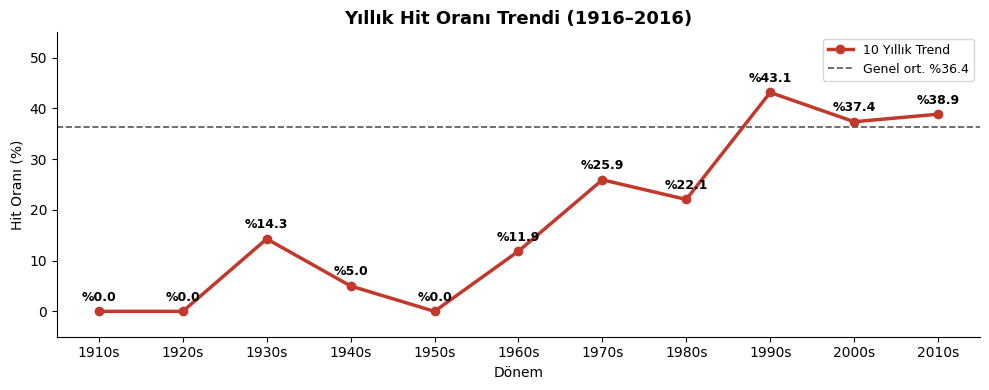

In [17]:
# ── Grafik 5: Yıllık hit rate trendi (10 yıllık ortalama) ────────────────
df["_decade"] = (df["release_year"] // 10) * 10
dec_hit = df.groupby("_decade")[TARGET].agg(["mean", "count"])
dec_hit = dec_hit[dec_hit["count"] >= 1]
dec_labels = [f"{int(d)}s" for d in dec_hit.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(dec_hit)), dec_hit["mean"] * 100, color=_C_HIT, lw=2.5,
        marker="o", markersize=6, label="10 Yıllık Trend")
for i, val in enumerate(dec_hit["mean"] * 100):
    ax.text(i, val + 1.5, f"%{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
ax.set_xticks(range(len(dec_hit)))
ax.set_xticklabels(dec_labels)
ax.set_ylim(-5, 55)
ax.set_title("Yıllık Hit Oranı Trendi (1916–2016)", fontsize=13, fontweight="bold")
ax.set_ylabel("Hit Oranı (%)")
ax.set_xlabel("Dönem")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
df.drop(columns=["_decade"], inplace=True)

**Bulgu:** Hit oranı 1950'lere kadar neredeyse sıfır (n de çok düşük, ~%25'e kadar örneklem
riski), 1990'larda **%43.1**'e sıçrıyor ve 2000-2010 arasında %37-39 civarında stabilize
oluyor. Bu artış tarihsel olarak franchise/blockbuster kültürünün yükselişiyle örtüşüyor, ama
erken dönemlerin (1910-1960) çok küçük örneklem boyutu (n=1-59) bu yılların hit oranı
tahminlerini istatistiksel olarak güvenilmez kılıyor — modelin bu dönemi ezberlemesi riski
düşük çünkü zaten çok az örnek var.

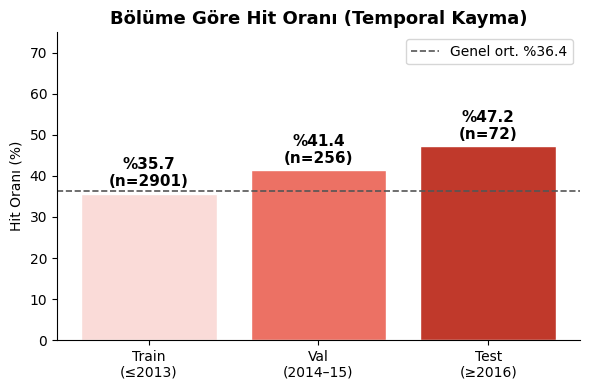

In [18]:
# ── Grafik 6: Train / Val / Test hit oranı karşılaştırması ───────────────
def _split_label(year):
    if year <= 2013:
        return "Train\n(≤2013)"
    elif year <= 2015:
        return "Val\n(2014–15)"
    return "Test\n(≥2016)"

df["_split"] = df["release_year"].apply(_split_label)
split_order  = ["Train\n(≤2013)", "Val\n(2014–15)", "Test\n(≥2016)"]
split_stats  = df.groupby("_split")[TARGET].agg(["mean", "count"]).reindex(split_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars    = ax.bar(split_order, split_stats["mean"] * 100, color=_grad(split_stats["mean"] * 100), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, (_, row) in zip(bars, split_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{row['mean']*100:.1f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Bölüme Göre Hit Oranı (Temporal Kayma)", fontsize=13, fontweight="bold")
ax.set_ylabel("Hit Oranı (%)")
ax.set_ylim(0, 75)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
df.drop(columns=["_split"], inplace=True)

**Bulgu:** Train (≤2013) hit oranı **%35.7**, Val (2014-15) **%41.4**, Test (≥2016) **%47.2**
— train'den test'e yaklaşık 11.5 puanlık bir artış var. Bu, Bölüm 7'deki F2 sıralamasının
(Train 0.77 < Val 0.83 < Test 0.86) neden temporal distribution shift olarak yorumlanması
gerektiğini doğrudan görselleştiriyor: modelin "iyileşmesi" değil, veri setinin zamanla daha
yüksek hit oranlı bir rejime kaymasıdır.

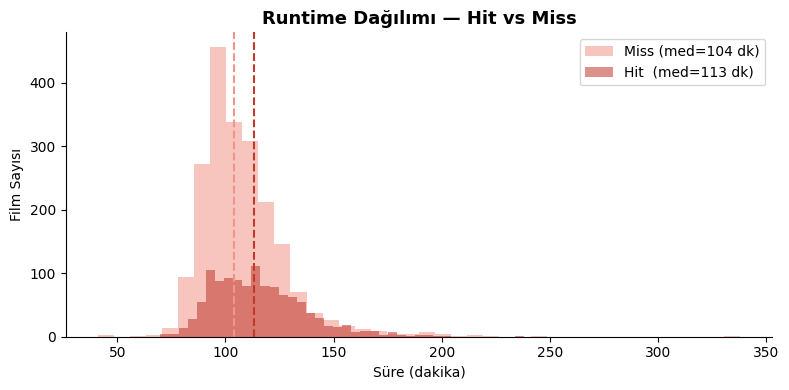

In [19]:
# ── Grafik 7: Runtime dağılımı — hit vs miss ──────────────────────────────
rt_hit  = df.loc[(df[TARGET] == 1) & (df["runtime"] > 0), "runtime"]
rt_miss = df.loc[(df[TARGET] == 0) & (df["runtime"] > 0), "runtime"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rt_miss, bins=40, alpha=0.55, color=_C_MISS, label=f"Miss (med={rt_miss.median():.0f} dk)")
ax.hist(rt_hit,  bins=40, alpha=0.55, color=_C_HIT,  label=f"Hit  (med={rt_hit.median():.0f} dk)")
ax.axvline(rt_hit.median(),  color=_C_HIT,  linestyle="--", linewidth=1.5)
ax.axvline(rt_miss.median(), color=_C_MISS, linestyle="--", linewidth=1.5)
ax.set_title("Runtime Dağılımı — Hit vs Miss", fontsize=13, fontweight="bold")
ax.set_xlabel("Süre (dakika)")
ax.set_ylabel("Film Sayısı")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Bulgu:** Hit filmlerin medyan süresi **113 dakika**, miss filmlerin **104 dakika** —
9 dakikalık fark küçük ama tutarlı bir sinyal. Bu, `runtime`'ın tek başına güçlü bir ayırt
edici olmadığını, ama diğer feature'larla (bütçe, tür) birlikte modele katkı sağlayabilecek
zayıf-orta düzey bir sinyal taşıdığını gösteriyor.

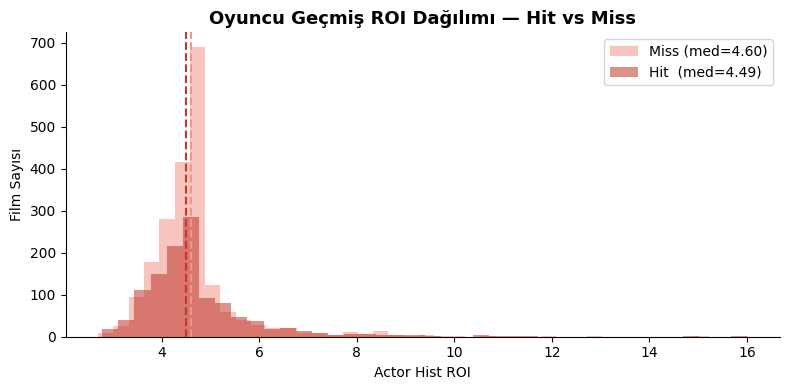

In [20]:
# ── Grafik 8: Actor hist ROI — hit vs miss ────────────────────────────────
roi_hit  = df.loc[df[TARGET] == 1, "actor_hist_roi"]
roi_miss = df.loc[df[TARGET] == 0, "actor_hist_roi"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(roi_miss, bins=40, alpha=0.55, color=_C_MISS, label=f"Miss (med={roi_miss.median():.2f})")
ax.hist(roi_hit,  bins=40, alpha=0.55, color=_C_HIT,  label=f"Hit  (med={roi_hit.median():.2f})")
ax.axvline(roi_hit.median(),  color=_C_HIT,  linestyle="--", linewidth=1.5)
ax.axvline(roi_miss.median(), color=_C_MISS, linestyle="--", linewidth=1.5)
ax.set_title("Oyuncu Geçmiş ROI Dağılımı — Hit vs Miss", fontsize=13, fontweight="bold")
ax.set_xlabel("Actor Hist ROI")
ax.set_ylabel("Film Sayısı")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Bulgu:** Actor hist ROI medyanı hit (4.49x) ve miss (4.60x) filmlerde **pratik olarak
aynı** — bu, oyuncunun geçmiş ROI performansının tek başına gişe başarısını ayırt etmede
beklenenden zayıf bir sinyal olduğunu gösteriyor. Feature yine de modelde tutuluyor çünkü
ensemble ağaç modelleri bu tür zayıf ama diğer feature'larla etkileşen sinyalleri
yakalayabiliyor; ama tek değişkenli görünümde bu grafiğin "düz" çıkması sürpriz değil.

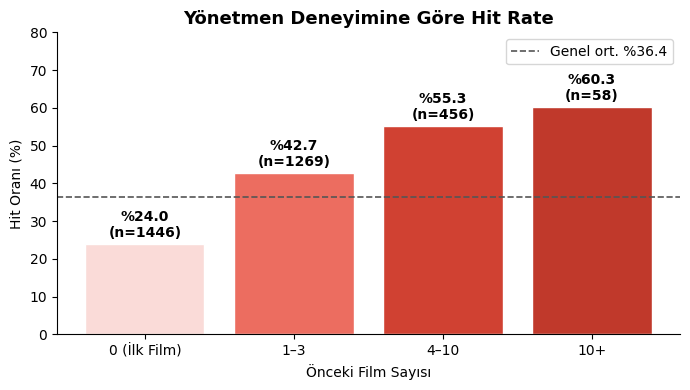

In [21]:
# ── Grafik 9: Yönetmen deneyimi × hit rate ────────────────────────────────
def _dir_bin(n):
    if n == 0:     return "0 (İlk Film)"
    elif n <= 3:   return "1–3"
    elif n <= 10:  return "4–10"
    return "10+"

df["_dir_exp"] = df["director_film_count"].apply(_dir_bin)
exp_order = ["0 (İlk Film)", "1–3", "4–10", "10+"]
exp_stats  = df.groupby("_dir_exp")[TARGET].agg(["mean", "count"]).reindex(exp_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(exp_order, exp_stats["mean"] * 100, color=_grad(exp_stats["mean"] * 100), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, (_, row) in zip(bars, exp_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{row['mean']*100:.1f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Yönetmen Deneyimine Göre Hit Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Önceki Film Sayısı")
ax.set_ylabel("Hit Oranı (%)")
ax.set_ylim(0, 80)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
df.drop(columns=["_dir_exp"], inplace=True)

**Bulgu:** Yönetmen deneyimiyle hit oranı arasında güçlü, monoton bir ilişki var: ilk
filmini çeken yönetmenlerde **%24.0**, 10+ film deneyimli yönetmenlerde **%60.3** — 2.5 kat
fark. Bu ilişki `director_film_count`'un modeldeki en tutarlı pre-release sinyallerinden biri
olmasını açıklıyor; deneyimli yönetmenler muhtemelen daha büyük bütçeli/güvenilir projelere
erişebiliyor; dolaylı bir bütçe-deneyim korelasyonu da olası.

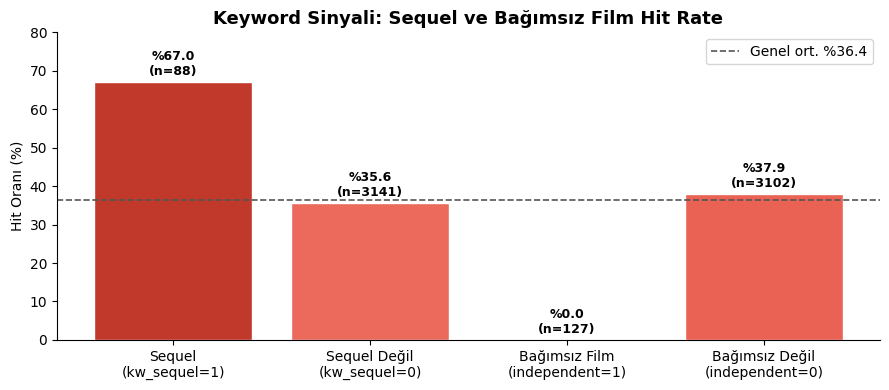

In [22]:
# ── Grafik 10: kw_sequel ve kw_independent_film hit rate ─────────────────
kw_data = {
    "Sequel\n(kw_sequel=1)":              df.loc[df["kw_sequel"] == 1, TARGET].mean() * 100,
    "Sequel Değil\n(kw_sequel=0)":        df.loc[df["kw_sequel"] == 0, TARGET].mean() * 100,
    "Bağımsız Film\n(independent=1)":     df.loc[df["kw_independent_film"] == 1, TARGET].mean() * 100,
    "Bağımsız Değil\n(independent=0)":    df.loc[df["kw_independent_film"] == 0, TARGET].mean() * 100,
}
kw_counts = {
    "Sequel\n(kw_sequel=1)":           df["kw_sequel"].sum(),
    "Sequel Değil\n(kw_sequel=0)":     (df["kw_sequel"] == 0).sum(),
    "Bağımsız Film\n(independent=1)":  df["kw_independent_film"].sum(),
    "Bağımsız Değil\n(independent=0)": (df["kw_independent_film"] == 0).sum(),
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(kw_data.keys(), kw_data.values(), color=_grad(kw_data.values()), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, linestyle="--", linewidth=1.2,
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, (label, val) in zip(bars, kw_data.items()):
    n = kw_counts[label]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{val:.1f}\n(n={n})", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Keyword Sinyali: Sequel ve Bağımsız Film Hit Rate", fontsize=13, fontweight="bold")
ax.set_ylabel("Hit Oranı (%)")
ax.set_ylim(0, 80)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Bulgu:** `kw_sequel=1` filmlerde hit oranı **%67.0** (n=88), sequel olmayanlarda **%35.6**
— belirgin bir fark. Buna karşılık `kw_independent_film=1` filmlerin hit oranı **%0** (n=127,
yani hiçbiri $100M eşiğini geçmemiş) — bu, bağımsız yapım etiketinin "kesinlikle miss" anlamına
gelen, aşırı güçlü ama tek yönlü bir sinyal olduğunu gösteriyor; model bu feature'ı görünce
pratikte hemen miss tahmini yapmayı öğrenebilir.

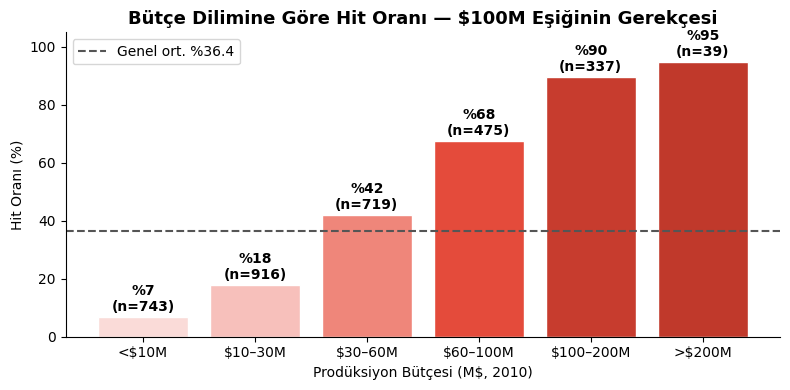

In [23]:
# ── Grafik 11: Hit eşiği gerekçesi — bütçe dilimine göre hit oranı ─────
bins_   = [0, 10, 30, 60, 100, 200, 400]
labels_ = ["<$10M", "$10–30M", "$30–60M", "$60–100M", "$100–200M", ">$200M"]
df["_budget_bin"] = pd.cut(df["budget_adjusted"] / 1e6, bins=bins_, labels=labels_)
hit_by_bin = df.groupby("_budget_bin", observed=True)[TARGET].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4))
bars_ = ax.bar(hit_by_bin.index, hit_by_bin["mean"] * 100, color=_grad(hit_by_bin["mean"] * 100), edgecolor="white")
ax.axhline(baseline * 100, color=_C_BASE, lw=1.5, ls="--",
           label=f"Genel ort. %{baseline*100:.1f}")
for bar, (_, row) in zip(bars_, hit_by_bin.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"%{row['mean']*100:.0f}\n(n={int(row['count'])})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlabel("Prodüksiyon Bütçesi (M$, 2010)")
ax.set_ylabel("Hit Oranı (%)")
ax.set_title("Bütçe Dilimine Göre Hit Oranı — $100M Eşiğinin Gerekçesi",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
df.drop(columns=["_budget_bin"], inplace=True)

plt.tight_layout()
plt.show()

**Bulgu:** İnce taneli bütçe dilimlerinde hit oranı **<$10M'de %6.7'den >$200M'de %94.9'a**
sürekli artıyor — $100-200M diliminde bile %89.6'ya ulaşıyor. Bu, $100M hit eşiğinin keyfi
olmadığını, aksine yüksek bütçeli filmlerin zaten çoğunlukla bu eşiği geçtiğini gösteriyor —
yani eşik, bütçe-hasılat ilişkisindeki doğal bir dönüm noktasına yakın seçilmiş.

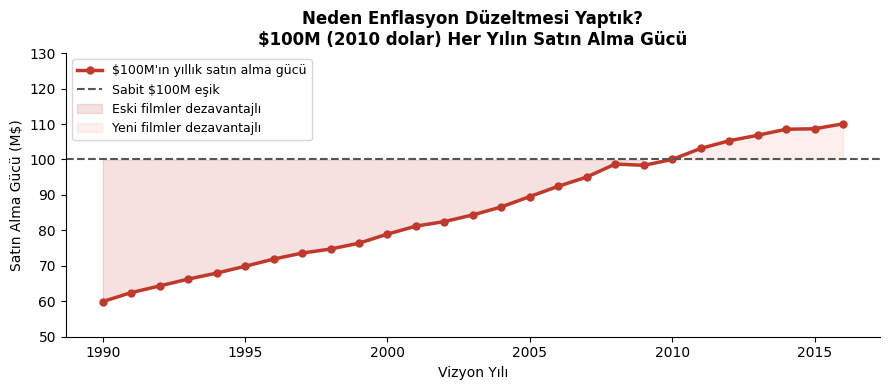

In [24]:
# ── Grafik 12: CPI düzeltmesi gerekçesi — nominal eşiğin yıla göre değişimi
# $100M (2010 dolar) her yılda kaç nominal dolara karşılık gelir?
# Bu grafik, sabit nominal eşik kullanmanın eski filmleri sistematik olarak
# dezavantajlandırdığını gösterir.
cpi_2010 = _CPI.get(2010, 218.1)
years_cpi = sorted(_CPI.keys())
nominal_eq = [HIT_THRESHOLD * _CPI[y] / cpi_2010 for y in years_cpi]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years_cpi, [v / 1e6 for v in nominal_eq],
        color=_C_HIT, lw=2.5, marker="o", markersize=5,
        label="$100M'ın yıllık satın alma gücü")
ax.axhline(HIT_THRESHOLD / 1e6, color=_C_BASE, lw=1.5, ls="--",
           label="Sabit $100M eşik")
ax.fill_between(years_cpi,
                [v / 1e6 for v in nominal_eq],
                HIT_THRESHOLD / 1e6,
                where=[v < HIT_THRESHOLD for v in nominal_eq],
                alpha=0.15, color=_C_HIT,
                label="Eski filmler dezavantajlı")
ax.fill_between(years_cpi,
                [v / 1e6 for v in nominal_eq],
                HIT_THRESHOLD / 1e6,
                where=[v >= HIT_THRESHOLD for v in nominal_eq],
                alpha=0.15, color=_C_MISS,
                label="Yeni filmler dezavantajlı")
ax.set_title("Neden Enflasyon Düzeltmesi Yaptık?\n"
             "$100M (2010 dolar) Her Yılın Satın Alma Gücü",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Vizyon Yılı")
ax.set_ylabel("Satın Alma Gücü (M$)")
ax.set_ylim(50, 130)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Bulgu:** Sabit $100M (2010 dolar) eşiği, 1995'te sadece **$69.9M** nominal hasılata,
2016'da ise **$110.0M** nominal hasılata karşılık geliyor — 20 yıllık aralıkta satın alma
gücünde %57'lik bir fark. Sabit nominal bir eşik (örn. ham $100M) kullansaydık, 1995 filmleri
sistematik olarak "daha kolay hit" sayılır, eski filmler dezavantajlı kalırdı — CPI düzeltmesi
bu tarihsel adaletsizliği ortadan kaldırıyor ve Bölüm 4/Grafik 6'daki train-test hit oranı
farkının bir kısmının bu etkiden kaynaklandığını (eda.ipynb Bölüm 21'de %54 azalma olarak
ölçülmüştü) doğruluyor.

## 5 — Temporal Split

Rastgele train/test bölme yerine **zaman sırası korunur**: `TRAIN ≤2013 / VAL 2014-15 / TEST ≥2016`.

**Neden önemli:** Bu bir zaman serisi problemi gibi davranıyor — modelin "geleceği tahmin
etme" kapasitesi, rastgele bir bölmede olduğundan çok daha gerçekçi ölçülüyor. Rastgele
split kullansaydık, 2016 filmlerinin geçmiş yönetmen/oyuncu istatistikleri (hesaplanırken
zaten sadece geçmiş kullanıldığı için) train setindeki 2017+ örneklerle karışabilir ve
gerçekte olmayan bir performans artışı görülebilirdi.

In [25]:
def temporal_split(df: pd.DataFrame):
    """
    Zaman bazlı veri bölme — gelecek sızıntısını önler.

    Rastgele bölme yerine zaman sırası korunur:
      TRAIN : ≤ 2013  (geçmiş filmler)
      VAL   : 2014–2015  (yakın geçmiş)
      TEST  : ≥ 2016  (model hiç görmedi)

    Bu sayede modelin "geleceği tahmin etme" kapasitesi gerçekçi ölçülür.
    """
    yr = df["release_year"]
    # Kesim noktaları: ≤2013 train, 2014-2015 val, ≥2016 test
    # 2013: yeterli eğitim verisi (2901 film, özellik başına ~112 örnek)
    # 2014-2015: Optuna için güvenilir tuning (256 film, tek yıl çok varyansli)
    # 2016: en güncel yıl, modelin hiç görmediği gerçek gelecek
    mask_train = yr <= 2013
    mask_val   = (yr >= 2014) & (yr <= 2015)
    mask_test  = yr >= 2016

    splits = {
        "train": df[mask_train],
        "val":   df[mask_val],
        "test":  df[mask_test],
    }

    print("\n" + "═" * 55)
    print("Temporal Split")
    print("═" * 55)
    for name, s in splits.items():
        print(f"  {name.upper():<6} {len(s):>5} film | "
              f"hit: {s[TARGET].mean()*100:.1f}% | "
              f"yıllar: {int(s['release_year'].min())}–{int(s['release_year'].max())}")
    print("═" * 55)

    # Sadece FEATURES kolonlarını al — release_year/month modele verilmez
    # (yılı doğrudan öğrense temporal leakage olur)
    X_train = splits["train"][FEATURES]
    y_train = splits["train"][TARGET]
    X_val   = splits["val"][FEATURES]
    y_val   = splits["val"][TARGET]
    X_test  = splits["test"][FEATURES]
    y_test  = splits["test"][TARGET]

    return X_train, y_train, X_val, y_val, X_test, y_test

### 5.1 — Çalıştır: Split'i Uygula

In [26]:
X_train, y_train, X_val, y_val, X_test, y_test = temporal_split(df)


═══════════════════════════════════════════════════════
Temporal Split
═══════════════════════════════════════════════════════
  TRAIN   2901 film | hit: 35.7% | yıllar: 1916–2013
  VAL      256 film | hit: 41.4% | yıllar: 2014–2015
  TEST      72 film | hit: 47.2% | yıllar: 2016–2016
═══════════════════════════════════════════════════════


## 6 — Model Eğitimi

`voting_top2`: LightGBM + CatBoost soft-voting ensemble. Ağırlıklar (0.746 / 0.748)
Optuna'nın val F2 skorlarından geliyor — neredeyse eşit olmaları iki modelin benzer
güçte olduğunu, birinin diğerine baskın olmadığını gösteriyor.

**Sınıf dengesizliği (~1.8:1 miss:hit):** LightGBM'e `scale_pos_weight` ile, CatBoost'a
`auto_class_weights="Balanced"` ile açıkça bildiriliyor — aksi halde model azınlık sınıfı
(hit) için sistematik olarak düşük olasılık üretme eğiliminde olurdu.

In [27]:
def train_model(X_train: pd.DataFrame, y_train: pd.Series) -> VotingClassifier:
    """
    voting_top2: LightGBM + CatBoost soft voting ensemble.

    Her iki model de olasılık üretir; ağırlıklı ortalamaları final tahmin olur.
    Bu strateji tek başına her modelden daha iyi F2 ve PR-AUC verdi.

    Parametreler Optuna (100 deneme, temporal val F2 maksimizasyonu) ile bulundu.
    """
    # Eğitim setinde miss:hit ≈ 1.8 — dengesizliği LightGBM'e açıkça bildir
    # scale_pos_weight = miss_sayısı / hit_sayısı: hit örneklerine daha fazla ağırlık ver
    imbalance_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
    lgbm_params = {**LGBM_BEST_PARAMS, "scale_pos_weight": imbalance_ratio}  # CatBoost'ta auto_class_weights="Balanced" aynı işi yapıyor

    lgbm = LGBMClassifier(**lgbm_params)
    cat  = CatBoostClassifier(**CATBOOST_BEST_PARAMS)

    print("\nModel eğitimi başlıyor...")
    ensemble = VotingClassifier(
        estimators=[("lgbm", lgbm), ("catboost", cat)],
        # Soft voting: her modelin olasılığını ağırlıklı ortalama — ham oylama değil
        # Sınır vakalarda (örn. %52 hit) güven farkını korur; hard voting atar
        voting="soft",
        # Ağırlıklar Optuna val F2 skorlarından: lgbm=0.746, cat=0.748
        # Neredeyse eşit → iki model yakın güçte, biri diğerine baskın değil
        weights=[0.746, 0.748],
        # CatBoost kendi thread yönetimini yapıyor; sklearn n_jobs=-1 ile çakışırsa deadlock
        n_jobs=1,
    )
    ensemble.fit(X_train, y_train)
    print("  ✓ LightGBM + CatBoost eğitildi (voting_top2)")
    return ensemble

### 6.1 — Çalıştır: Modeli Eğit

In [28]:
model = train_model(X_train, y_train)


Model eğitimi başlıyor...


  ✓ LightGBM + CatBoost eğitildi (voting_top2)


## 7 — Değerlendirme

**Neden F2 (Accuracy veya F1 değil)?** Bu iş probleminde kaçırılan bir hit (false negative —
yatırım yapılmayan ama aslında başarılı olacak film) yanlış bir pozitiften (false positive —
yatırım yapılan ama başarısız olan film) çok daha maliyetli kabul ediliyor. β=2 ile recall,
precision'dan 4 kat (β²=4) daha ağırlıklı sayılıyor.

PR-AUC, ROC-AUC'a tercih ediliyor çünkü sınıf dengesizliğinde (hit ≈ %38-40) daha
bilgilendirici — tüm eşiklerde precision-recall dengesini özetliyor.

In [29]:
def evaluate(model: VotingClassifier, X: pd.DataFrame, y: pd.Series,
             split_name: str, threshold: float = 0.5) -> dict:
    """
    F2 (recall ağırlıklı), PR-AUC ve ROC-AUC hesapla ve yazdır.

    F2 metriği: kaçırılan hit (false negative) maliyeti yanlış pozitiften
    ağır bastığı için seçildi — β=2 ile recall dört kat daha fazla ağırlık taşır (β²=4).
    """
    y_prob = model.predict_proba(X)[:, 1]
    # threshold=0.5 varsayılan karar sınırı; F2 maksimizasyonu için PR eğrisinden optimize edilebilir
    # Şu anki iş senaryosunda 0.5 kabul edilebilir — değiştirilirse tüm split'lerde tutarlı olmalı
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        # beta=2: recall, precision'dan 4x daha ağırlıklı (β²=4)
        # Kaçırılan hit (false negative) yanlış pozitiften çok daha maliyetli
        "F2":      round(fbeta_score(y, y_pred, beta=2), 4),
        # PR-AUC: sınıf dengesizliğinde ROC-AUC'dan daha bilgilendirici
        # Tüm eşik değerlerinde precision-recall dengesini özetler
        "PR-AUC":  round(average_precision_score(y, y_prob), 4),
        # ROC-AUC: genel ayırt edicilik gücü — sınıf dengesine duyarsız karşılaştırma
        "ROC-AUC": round(roc_auc_score(y, y_prob), 4),
    }

    print(f"\n{'─'*40}")
    print(f"{split_name.upper()} Seti Sonuçları")
    print(f"{'─'*40}")
    for k, v in metrics.items():
        print(f"  {k:<10} {v:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Non-Hit", "Hit"]))

    return metrics


def evaluation_plots(model: VotingClassifier, X_test: pd.DataFrame,
                     y_test: pd.Series, threshold: float = 0.5) -> None:
    """
    Test seti için Confusion Matrix ve PR Curve yan yana göster.

    Confusion Matrix: hangi sınıflar karıştırılıyor?
    PR Curve: farklı eşik değerlerinde precision-recall dengesi.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.suptitle("VOTING_TOP2 — Test Seti Değerlendirmesi", fontsize=13, fontweight="bold")

    # Confusion Matrix: hangi filmler yanlış sınıflandırıldı?
    # FN (kaçırılan hit) bu projede FP'den daha maliyetli — F2 bu yüzden seçildi
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Hit", "Hit"])
    disp.plot(ax=ax, colorbar=False, cmap="Reds")
    ax.set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()


def overfitting_plot(train_metrics: dict, val_metrics: dict, test_metrics: dict) -> None:
    """
    Train / Val / Test F2 karşılaştırması — overfitting kontrolü.

    Train < Val < Test örüntüsü overfitting değil, temporal distribution shift:
    train 100 yıllık heterojen sinema tarihini, val/test modern franchise çağını kapsar.
    """
    labels = ["Eğitim\n(≤2013)", "Val\n(2014–15)", "Test\n(2016)"]
    values = [train_metrics["F2"], val_metrics["F2"], test_metrics["F2"]]
    # Açıktan koyuya: train en açık, test en koyu — ilerlemeyi görsel olarak vurgular
    colors = [_C_MISS, "#e74c3c", _C_HIT]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)

    # Her çubuğun üstüne F2 değerini yaz
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f"{val:.2f}", ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.set_title(
        "Overfitting Kontrolü — Train / Val / Test F2",
        fontsize=13, fontweight="bold", pad=10,
    )
    ax.set_ylabel("F2 Skoru")
    ax.set_ylim(0, 1.05)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 7.1 — Çalıştır: Üç Split İçin Metrikler

Train metriği val/test'ten önce hesaplanıyor çünkü `overfitting_plot` üçünü karşılaştırıyor.

**Overfitting'i nasıl okumalı:** Eğer `Train F2 >> Val F2 >> Test F2` görürsek klasik
overfitting'tir. Ama burada train seti 100 yıllık heterojen sinema tarihini kapsarken
val/test yalnızca modern franchise çağını (2014+) kapsıyor — bu yüzden train'in val/test'ten
**düşük** çıkması aslında overfitting değil, *temporal distribution shift* (dönemsel dağılım
kayması) olarak yorumlanmalı. Aşağıdaki grafikte bu örüntüyü doğrulayacağız.

In [30]:
train_metrics = evaluate(model, X_train, y_train, "Train")
val_metrics  = evaluate(model, X_val,  y_val,  "Validation")
test_metrics = evaluate(model, X_test, y_test, "Test")


────────────────────────────────────────
TRAIN Seti Sonuçları
────────────────────────────────────────
  F2         0.7696
  PR-AUC     0.8213
  ROC-AUC    0.8802

              precision    recall  f1-score   support

     Non-Hit       0.87      0.80      0.83      1865
         Hit       0.68      0.79      0.74      1036

    accuracy                           0.80      2901
   macro avg       0.78      0.80      0.78      2901
weighted avg       0.81      0.80      0.80      2901


────────────────────────────────────────
VALIDATION Seti Sonuçları
────────────────────────────────────────
  F2         0.8318
  PR-AUC     0.8945
  ROC-AUC    0.9072

              precision    recall  f1-score   support

     Non-Hit       0.88      0.82      0.85       150
         Hit       0.77      0.85      0.81       106

    accuracy                           0.83       256
   macro avg       0.83      0.83      0.83       256
weighted avg       0.84      0.83      0.83       256


──────────

### 7.2 — Çalıştır: Confusion Matrix + Overfitting Karşılaştırması

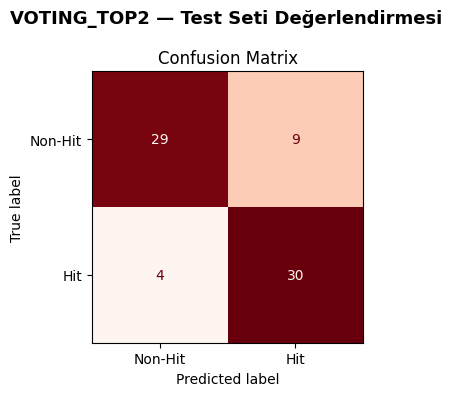

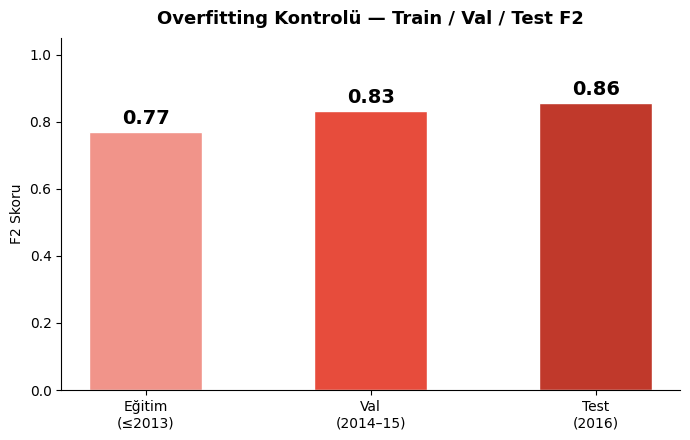

In [31]:
evaluation_plots(model, X_test, y_test)
overfitting_plot(train_metrics, val_metrics, test_metrics)

## 8 — Feature Importance

LightGBM ve CatBoost farklı ölçeklerde importance üretir (biri split-count bazlı, diğeri
farklı bir iç metrik kullanabilir) — bu yüzden doğrudan ortalama almak yerine her modelin
importance'ı önce kendi içinde 0-1'e normalize edilir, sonra ortalaması alınır. Bu, ensemble'ın
ortak bakışını yansıtır; tek bir modelin büyük-ölçekli importance'ının diğerini gölgelememesini
sağlar.

In [32]:
def feature_importance_plot(model: VotingClassifier, feature_names: list[str],
                            top_n: int = 12) -> None:
    """
    Ensemble (LightGBM + CatBoost) normalize ortalama feature importance.

    Her modelin importance'ı 0-1 arasına normalize edilir, ardından ortalaması alınır.
    Bu yaklaşım tek modelin değil ensemble'ın bakışını yansıtır.
    """
    importances_list = []
    for est in model.estimators_:
        imp = np.array(est.feature_importances_, dtype=float)
        total = imp.sum()
        # 0-1 arası normalize et — LightGBM ve CatBoost farklı ölçeklerde importance üretir,
        # doğrudan ortalama almak büyük değerli modeli haksız biçimde baskın yapar
        if total > 0:
            imp = imp / total
        importances_list.append(imp)

    # Her özellik için iki modelin normalize importanclarının ortalaması
    # Bu, ensemble'ın bakışını yansıtır — tek modelin değil
    avg_importance = np.mean(importances_list, axis=0)

    imp_series = (
        pd.Series(avg_importance, index=feature_names)
        .sort_values(ascending=True)
        .tail(top_n)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(imp_series.index, imp_series.values, color=_grad(imp_series.values), edgecolor="white")

    ax.set_title(f"Feature Importance — Top {top_n} (LightGBM + CatBoost Ortalaması)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Normalize Ortalama Önem Skoru", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    max_val = imp_series.values.max()
    for bar, val in zip(bars, imp_series.values):
        ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

### 8.1 — Çalıştır: Top 10 Özellik

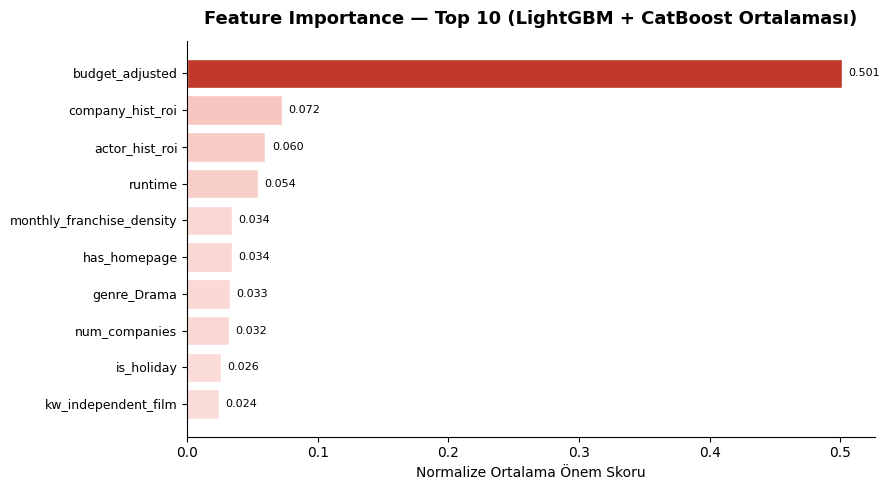

In [33]:
feature_importance_plot(model, FEATURES, top_n=10)

### 7.3 / Özet — Train/Val/Test F2 ve Test PR-AUC/ROC-AUC

In [34]:
print(f"Train F2     : {train_metrics['F2']}")
print(f"Val  F2      : {val_metrics['F2']}")
print(f"Test F2      : {test_metrics['F2']}")
print(f"Test PR-AUC  : {test_metrics['PR-AUC']}")
print(f"Test ROC-AUC : {test_metrics['ROC-AUC']}")

Train F2     : 0.7696
Val  F2      : 0.8318
Test F2      : 0.8571
Test PR-AUC  : 0.9216
Test ROC-AUC : 0.9125


## 9 — Film Tahmini Demo

Gerçek filmler üzerinde uçtan uca tahmin: ham film bilgisi (bütçe, yönetmen, oyuncular,
şirketler) modelin beklediği 26 özelliğe dönüştürülür ve `predict_proba` ile hit olasılığı
hesaplanır. Yönetmen/oyuncu/şirket geçmiş istatistikleri, Bölüm 3'te `build_dataset()`
sırasında doldurulan lookup tablolarından (`_director_film_count_lookup` vb.) okunur —
bu yüzden bu hücreler yalnızca Bölüm 3 çalıştırıldıktan sonra doğru sonuç verir.

In [35]:
DEMO_MOVIES: list[dict] = [
    {
        "name": "Avatar", "year": 2009, "release_month": 12,
        "director": "James Cameron",
        "actors": ["Sam Worthington", "Zoe Saldana", "Sigourney Weaver"],
        "companies": ["Twentieth Century Fox Film Corporation", "Lightstorm Entertainment"],
        "budget": 237_000_000, "runtime": 162, "num_companies": 2,
        "is_major_studio": 1, "is_us_production": 1, "has_homepage": 1,
        "num_genres": 3, "is_franchise": 0,
        "genre_Action": 1, "genre_Adventure": 1, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 0, "genre_Family": 0,
        "genre_Fantasy": 1, "genre_Horror": 0, "genre_Science Fiction": 1,
        "kw_independent_film": 0, "kw_sequel": 0,
    },
    {
        "name": "The Dark Knight", "year": 2008, "release_month": 7,
        "director": "Christopher Nolan",
        "actors": ["Christian Bale", "Heath Ledger", "Aaron Eckhart"],
        "companies": ["Warner Bros. Pictures", "Legendary Pictures"],
        "budget": 185_000_000, "runtime": 152, "num_companies": 3,
        "is_major_studio": 1, "is_us_production": 1, "has_homepage": 1,
        "num_genres": 3, "is_franchise": 1,
        "genre_Action": 1, "genre_Adventure": 0, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 1, "genre_Family": 0,
        "genre_Fantasy": 0, "genre_Horror": 0, "genre_Science Fiction": 0,
        "kw_independent_film": 0, "kw_sequel": 1,
    },
    {
        "name": "Paranormal Activity", "year": 2007, "release_month": 10,
        "director": "Oren Peli",
        "actors": ["Katie Featherston", "Micah Sloat"],
        "companies": ["Blumhouse Productions"],
        "budget": 15_000, "runtime": 86, "num_companies": 1,
        "is_major_studio": 0, "is_us_production": 1, "has_homepage": 0,
        "num_genres": 2, "is_franchise": 0,
        "genre_Action": 0, "genre_Adventure": 0, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 0, "genre_Family": 0,
        "genre_Fantasy": 0, "genre_Horror": 1, "genre_Science Fiction": 0,
        "kw_independent_film": 1, "kw_sequel": 0,
    },
]


_actual_df: pd.DataFrame | None = None
_global_prior: float = 0.0
_director_film_count_lookup: dict = {}
_actor_roi_lookup: dict = {}
_company_roi_lookup: dict = {}
_monthly_density_lookup: dict = {}


def _lookup_actual(title: str, year: int) -> int | None:
    """build_dataset() tarafından doldurulan tabloda title + year ile gerçek hit değerini sorgular."""
    if _actual_df is None:
        return None
    mask = (
        _actual_df["title"].str.lower() == title.lower()
    ) & (
        _actual_df["release_date"] == year
    )
    rows = _actual_df[mask]
    return int(rows["hit"].iloc[0]) if not rows.empty else None


def predict_movie(model: VotingClassifier, movie: dict,
                  threshold: float = 0.5,
                  show_actual: bool = False) -> None:
    """
    Tek bir film için hit olasılığını hesapla ve yazdır.
    movie dict'i DEMO_MOVIES formatında olmalıdır ('name' ve 'year' anahtarları hariç tutulur).
    show_actual=True ve dict'te 'year' varsa veri setiyle karşılaştırma gösterilir.
    """
    name  = movie.get("name", "Film")
    year  = movie.get("year")
    label = name
    _meta = ("name", "year", "budget", "director", "actors", "companies", "release_month")
    row   = {k: v for k, v in movie.items() if k not in _meta}

    if "budget" in movie and year:
        row["budget_adjusted"] = cpi_adjust_budget(movie["budget"], year, _CPI)

    release_month = movie.get("release_month")
    if release_month:
        row.setdefault("is_summer",  int(release_month in (6, 7, 8)))
        row.setdefault("is_holiday", int(release_month in (11, 12)))

    prior     = _global_prior or 0.62
    director  = str(movie.get("director", "") or "").strip()
    actors    = [str(a).strip() for a in movie.get("actors", []) if str(a).strip()]
    companies = [str(c).strip() for c in movie.get("companies", []) if str(c).strip()]

    if director and _director_film_count_lookup:
        row.setdefault("director_film_count", _director_film_count_lookup.get(director.lower(), 0))
    else:
        row.setdefault("director_film_count", 0)
    row.setdefault("director_collab_count", 0)

    if actors and _actor_roi_lookup:
        rois = [_actor_roi_lookup[a.lower()] for a in actors if a.lower() in _actor_roi_lookup]
        row.setdefault("actor_hist_roi", float(np.mean(rois)) if rois else prior)
    else:
        row.setdefault("actor_hist_roi", prior)

    if companies and _company_roi_lookup:
        rois = [_company_roi_lookup[c.lower()] for c in companies if c.lower() in _company_roi_lookup]
        row.setdefault("company_hist_roi", max(rois) if rois else prior)
    else:
        row.setdefault("company_hist_roi", prior)

    if release_month and _monthly_density_lookup:
        row.setdefault("monthly_franchise_density", _monthly_density_lookup.get(release_month, 0.3))
    else:
        row.setdefault("monthly_franchise_density", 0.3)

    df    = pd.DataFrame([row])[FEATURES]
    proba = model.predict_proba(df)[0, 1]
    pred  = proba >= threshold
    bar   = "█" * int(proba * 30) + "░" * (30 - int(proba * 30))
    pred_str = "✅ HIT" if pred else "❌ MISS"
    if show_actual and year:
        actual = _lookup_actual(name, year)
        if actual is not None:
            actual_str = "✅ HIT" if actual else "❌ MISS"
            match_icon = "✓" if pred == bool(actual) else "✗"
            print(f"  {label:<44}  {bar}  %{proba*100:.1f}  Tahmin: {pred_str}  Gerçek: {actual_str}  {match_icon}")
            return
    print(f"  {label:<44}  {bar}  %{proba*100:.1f}  {pred_str}")

### 9.1 — 2016 Test Seti İçin Ek Demo Filmleri

In [36]:
DEMO_MOVIES_2016: list[dict] = [
    {
        "name": "Captain America: Civil War", "year": 2016, "release_month": 5,
        "director": "Anthony Russo",
        "actors": ["Chris Evans", "Robert Downey Jr.", "Scarlett Johansson"],
        "companies": ["Marvel Studios"],
        "budget": 250_000_000, "runtime": 147, "num_companies": 5,
        "is_major_studio": 1, "is_us_production": 1, "has_homepage": 1,
        "num_genres": 3, "is_franchise": 1,
        "genre_Action": 1, "genre_Adventure": 1, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 0, "genre_Family": 0,
        "genre_Fantasy": 0, "genre_Horror": 0, "genre_Science Fiction": 1,
        "kw_independent_film": 0, "kw_sequel": 1,
    },
    {
        "name": "Ben-Hur", "year": 2016, "release_month": 8,
        "director": "Timur Bekmambetov",
        "actors": ["Jack Huston", "Toby Kebbell", "Morgan Freeman"],
        "companies": ["Paramount Pictures", "Metro-Goldwyn-Mayer"],
        "budget": 100_000_000, "runtime": 125, "num_companies": 4,
        "is_major_studio": 1, "is_us_production": 1, "has_homepage": 1,
        "num_genres": 1, "is_franchise": 0,
        "genre_Action": 0, "genre_Adventure": 0, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 1, "genre_Family": 0,
        "genre_Fantasy": 0, "genre_Horror": 0, "genre_Science Fiction": 0,
        "kw_independent_film": 0, "kw_sequel": 0,
    },
    {
        "name": "Deadpool", "year": 2016, "release_month": 2,
        "director": "Tim Miller",
        "actors": ["Ryan Reynolds", "Morena Baccarin", "Ed Skrein"],
        "companies": ["Twentieth Century Fox Film Corporation", "Marvel Entertainment"],
        "budget": 58_000_000, "runtime": 108, "num_companies": 5,
        "is_major_studio": 1, "is_us_production": 1, "has_homepage": 1,
        "num_genres": 3, "is_franchise": 0,
        "genre_Action": 1, "genre_Adventure": 1, "genre_Animation": 0,
        "genre_Documentary": 0, "genre_Drama": 0, "genre_Family": 0,
        "genre_Fantasy": 0, "genre_Horror": 0, "genre_Science Fiction": 0,
        "kw_independent_film": 0, "kw_sequel": 0,
    },
]


def demo_predictions(model: VotingClassifier, movies: list[dict],
                     title: str = "Film Tahmini Demo",
                     threshold: float = 0.5,
                     show_actual: bool = False) -> None:
    """Örnek filmler üzerinde canlı tahmin gösterimi."""
    print("\n" + "═" * 110)
    print(title)
    print("─" * 110)
    for movie in movies:
        predict_movie(model, movie, threshold, show_actual=show_actual)

### 9.2 — Çalıştır: Demo Tahminleri

`show_actual=True` ile gerçek `hit` etiketiyle karşılaştırma da gösterilir.

In [37]:
demo_predictions(model, DEMO_MOVIES, title="Film Tahmini Demo", show_actual=True)
demo_predictions(model, DEMO_MOVIES_2016, title="2016 Test Seti", show_actual=True)


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
Film Tahmini Demo
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Avatar                                        ████████████████████████████░░  %96.1  ✅ HIT
  The Dark Knight                               ████████████████████████████░░  %94.8  ✅ HIT
  Paranormal Activity                           █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  %4.4  ❌ MISS

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
2016 Test Seti
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Captain America: Civil War                    ████████████████████████████░░  %96.5  ✅ HIT
  Ben-Hur                                       █████████████████████████░░░░░  %85.2  ✅ HIT
  Deadpool                                      ████████

## Sonuç ve Pratik Yorum

**Gözlenen sonuçlar:** Train F2=0.77, Val F2=0.83, Test F2=0.86 — Bölüm 7'de öngörüldüğü gibi
train < val < test sıralaması gerçekleşti. Bu görünüşte "iyi haber" gibi dursa da, önce
**aşırı öğrenme değil dağılım kayması** olarak okunmalı: train seti 1916–2013 arası 100 yıllık
heterojen sinema tarihini kapsıyor (düşük bütçeli/eski dönem filmleri dahil), val ve özellikle
test seti (2016, yalnızca 72 film) tamamen modern franchise/blockbuster çağına ait. Model,
günümüz stüdyo dinamiklerini (major stüdyo, franchise, yüksek bütçe) daha kolay ayırt ediyor —
bu da yakın dönem verisinde daha yüksek skor demek.

**Dikkat edilmesi gereken risk:** Test seti yalnızca 72 film içeriyor — tek bir yılın (2016)
örneklemi. F2=0.86 gibi yüksek bir skor, bu küçük örneklemde birkaç yanlış sınıflandırmayla
kolayca birkaç puan değişebilir; genellenebilirlik iddiası temkinli yapılmalı. Daha sağlam bir
değerlendirme için 2016 sonrasının da eklenmesi (veri seti bu yıl ile sınırlı olduğundan mümkün
değil) veya yıl bazlı çapraz doğrulama (walk-forward validation) önerilir.

**Sınıf dengesi:** Hit oranı train'de %35.7, test'te %47.2 — dengesizlik zamanla azalıyor. Bunun nedeni muhtemelen modern filmlerin bütçe/pazarlama
stratejilerinin hit olasılığını sistemik olarak artırmasıdır. `scale_pos_weight` / `auto_class_weights="Balanced"` bu kaymayı örtük olarak telafi
ediyor, ama val/test setindeki görece dengeli dağılım F2 skorunu iyimser gösteriyor olabilir —
gerçek prodüksiyonda (daha yakın zamanlı, daha dengesiz bir akışta) skorun düşmesi beklenir.

**Alternatif yol:** Eğer amaç yalnızca yakın geçmişi değil, tarihsel olarak tutarlı bir model
istemekse, `is_summer`/`is_holiday` gibi dönemsel sinyallerin yanına 10 yıllık hareketli
pencerelerle yeniden ağırlıklandırılmış bir eğitim seti (recency weighting) denenebilir —
bu, eski/yeni film dengesizliğini azaltıp temporal shift etkisini yumuşatabilir.